# GRA: lion + imgnet + ResNet18

project = ```GRA```, host = ```yoru```, device = ```cuda:1```

## Goals:

Test these Lion extensions:

**relativistic**

on `ImageNet` w/ `ResNet18` architectrue

In [1]:
# HIDE CODE


project_name = '_GRA'


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-progress-2025/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-progress-2025/figs')
tmp_dir = os.path.join(git_dir, 'jb-progress-2025/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, project_name))
from utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: yoru

## Main

In [3]:
from optimzers import *
from test.test import *

### ImgNet32

`batch_size = 256`

In [4]:
cfg = TrainConfig(
    dataset='ImageNet32',
    batch_size=256,
    epochs=50,
    device=device,
    data_on_device=False,
    verbose=True,
    amp=False,
)

In [5]:
lr = 1e-3
beta1 = 0.8
kws = dict(lr=lr, betas=(beta1, 0.99), use_curvature=False)


experiments = [Experiment(
    f"Rel Lion — lr={lr},b1={beta1},mass={m}",
    make_opt(RelativisticLion, mass=m, **kws),
) for m in [100]]

experiments.extend([Experiment(
    f"Adam — lr={lr},b1={b1}",
    make_opt(torch.optim.Adam, lr=1e-3, betas=(b1, 0.99)),
) for b1 in [0.8, 0.9]])

print(experiments)

[
    Experiment(
        name='Rel Lion — lr=0.001,b1=0.8,mass=100',
        opt_fn=<function make_opt.<locals>._fn at 0x7fd01cde4720>
    ),
    Experiment(name='Adam — lr=0.001,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x7fd01cde4c20>),
    Experiment(name='Adam — lr=0.001,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x7fd01aee7ec0>)
]

In [6]:
results = run_experiments(
    experiments=experiments,
    cfg=cfg,
    model_class=ResNet18,
    model_kws=dict(num_classes=1000),
    seeds=[0],
)

--- Training (ImageNet32) ---

Model: ResNet18({'num_classes': 1000}) | seed=0
Optimizer: RelativisticLion

RelativisticLion (
Parameter Group 0
    betas: (0.8, 0.99)
    lr: 0.001
    mass: 100
    use_curvature: False
    weight_decay: 0.0
)

Epoch    1/50:  Train Loss 4.3671  |  Test Acc 25.93%

Epoch    2/50:  Train Loss 3.0958  |  Test Acc 33.57%

Epoch    3/50:  Train Loss 2.6356  |  Test Acc 36.03%

...

Epoch   47/50:  Train Loss 0.1196  |  Test Acc 32.15%

Epoch   48/50:  Train Loss 0.1172  |  Test Acc 32.59%

Epoch   49/50:  Train Loss 0.1143  |  Test Acc 32.28%

Epoch   50/50:  Train Loss 0.1117  |  Test Acc 32.50%

Finished in 11905.1s

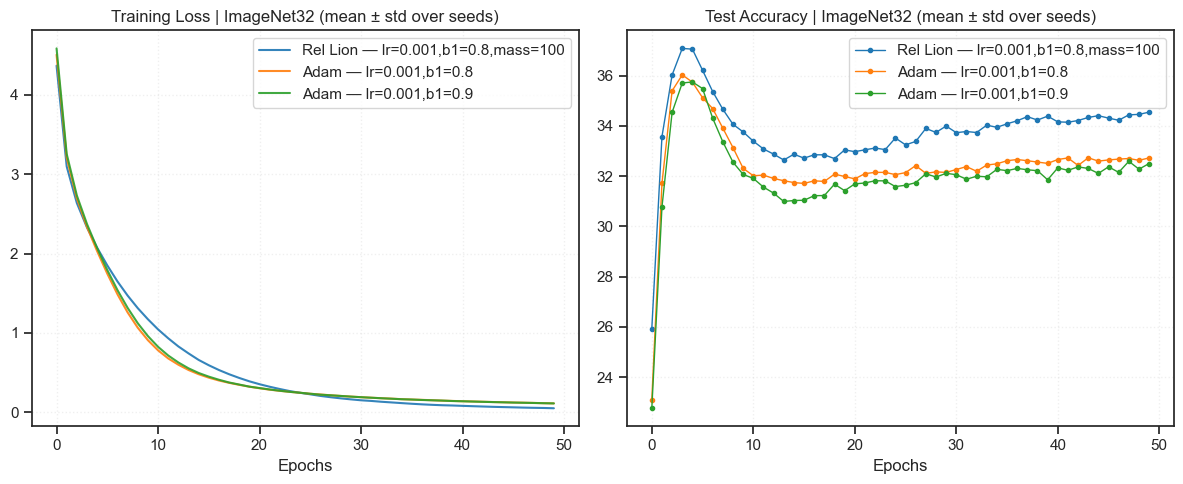

In [7]:
plot_results(results, title="ImageNet32 (mean ± std over seeds)")

In [9]:
avg_scores = {k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2) for k, d in results.items()}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'Adam — lr=0.001,b1=0.9': 32.38,
 'Adam — lr=0.001,b1=0.8': 32.68,
 'Rel Lion — lr=0.001,b1=0.8,mass=100': 34.4}

In [10]:
lr = 1e-3
beta1 = 0.8
kws = dict(lr=lr, betas=(beta1, 0.99), use_curvature=False)


experiments = [Experiment(
    f"Rel Lion — lr={lr},b1={beta1},mass={m}",
    make_opt(RelativisticLion, mass=m, **kws),
) for m in [10, 1000]]

experiments += [
    Experiment(f"Lion — lr=1e-4,b1=0.8", make_opt(Lion, lr=1e-4, betas=(0.8,0.99))),
    Experiment(f"Lion — lr=1e-4,b1=0.9", make_opt(Lion, lr=1e-4, betas=(0.9,0.99))),
    Experiment(f"Lion — lr={lr},b1=0.8", make_opt(Lion, lr=lr, betas=(0.8,0.99))),
    Experiment(f"SGD — lr={lr},b1=0.9", make_opt(torch.optim.SGD, lr=lr)),
]

print(experiments)

[
    Experiment(
        name='Rel Lion — lr=0.001,b1=0.8,mass=10',
        opt_fn=<function make_opt.<locals>._fn at 0x7fd01a919ee0>
    ),
    Experiment(
        name='Rel Lion — lr=0.001,b1=0.8,mass=1000',
        opt_fn=<function make_opt.<locals>._fn at 0x7fd01a919f80>
    ),
    Experiment(name='Lion — lr=1e-4,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x7fd01aee7ec0>),
    Experiment(name='Lion — lr=1e-4,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x7fd01a919e40>),
    Experiment(name='Lion — lr=0.001,b1=0.8', opt_fn=<function make_opt.<locals>._fn at 0x7fd01a91a020>),
    Experiment(name='SGD — lr=0.001,b1=0.9', opt_fn=<function make_opt.<locals>._fn at 0x7fd01a91a0c0>)
]

In [11]:
%%time


results_new = run_experiments(
    experiments=experiments,
    cfg=cfg,
    model_class=ResNet18,
    model_kws=dict(num_classes=1000),
    seeds=[0],
)

--- Training (ImageNet32) ---

Model: ResNet18({'num_classes': 1000}) | seed=0
Optimizer: RelativisticLion

RelativisticLion (
Parameter Group 0
    betas: (0.8, 0.99)
    lr: 0.001
    mass: 10
    use_curvature: False
    weight_decay: 0.0
)

Epoch    1/50:  Train Loss 4.4441  |  Test Acc 26.27%

Epoch    2/50:  Train Loss 3.0773  |  Test Acc 34.20%

Epoch    3/50:  Train Loss 2.5886  |  Test Acc 36.92%

...

Epoch   48/50:  Train Loss 4.4679  |  Test Acc 13.10%

Epoch   49/50:  Train Loss 4.4440  |  Test Acc 13.22%

Epoch   50/50:  Train Loss 4.4205  |  Test Acc 13.52%

Finished in 11653.0s

CPU times: user 20h 18min 35s, sys: 2min 4s, total: 20h 20min 40s
Wall time: 20h 19min 11s


In [12]:
combined = results | results_new

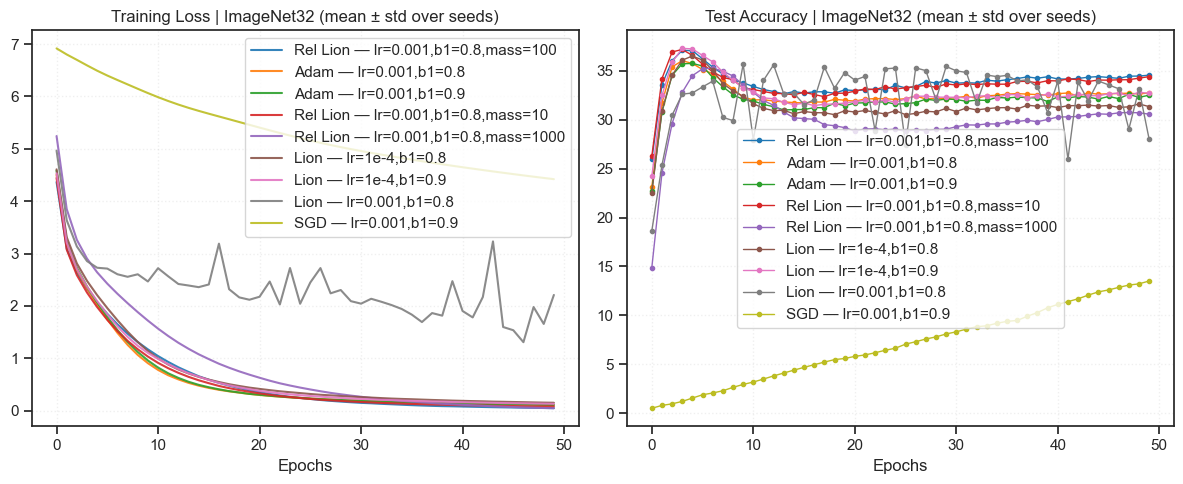

In [13]:
plot_results(combined, title="ImageNet32 (mean ± std over seeds)")

In [14]:
avg_scores = {
    k: np.round(d['test_acc'].squeeze()[-5:].mean(), decimals=2)
    for k, d in combined.items()
}
avg_scores = dict(sorted(avg_scores.items(), key=lambda t: t[1]))
avg_scores

{'SGD — lr=0.001,b1=0.9': 13.06,
 'Rel Lion — lr=0.001,b1=0.8,mass=1000': 30.65,
 'Lion — lr=0.001,b1=0.8': 31.38,
 'Lion — lr=1e-4,b1=0.8': 31.39,
 'Adam — lr=0.001,b1=0.9': 32.38,
 'Lion — lr=1e-4,b1=0.9': 32.66,
 'Adam — lr=0.001,b1=0.8': 32.68,
 'Rel Lion — lr=0.001,b1=0.8,mass=10': 34.17,
 'Rel Lion — lr=0.001,b1=0.8,mass=100': 34.4}